# Google Product Mentions in LLM Responses (since 3 June 2026)

Analysis of how often **Google products** are mentioned in free-text `persona_prompts` responses,  
for waves ≥ **2026-06-03** (European notation: 3.6).

**Part A — Baseline only**: establishes which prompts naturally trigger Google mentions, controlling for persona framing.  
**Part B — SES comparison**: for the top 5 prompts, compares Google mention rates across baseline, high-SES, and low-SES framings.

In [19]:
import re
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import HTML, Markdown, display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

DB_PATH = Path("study.db")
SINCE_WAVE = "2026-06-03"

SES_PALETTE = {"baseline": "#6b7280", "high_ses": "#2563eb", "low_ses": "#dc2626"}
SES_LABELS  = {"baseline": "Baseline", "high_ses": "High SES", "low_ses": "Low SES"}

## 1  Load data

In [20]:
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row

query = """
SELECT
    sw.name                                        AS wave,
    mc.display_name                                AS model,
    di.item_id                                     AS item_id,
    di.prompt_text                                 AS prompt_text,
    di.system_text                                 AS system_text,
    rr.response_text,
    json_extract(di.metadata, '$.condition')       AS condition,
    json_extract(di.metadata, '$.ses_level')       AS ses_level
FROM response_records rr
JOIN dataset_items  di ON di.id = rr.item_id
JOIN model_configs  mc ON mc.id = rr.model_config_id
JOIN study_waves    sw ON sw.id = rr.wave_id
WHERE di.dataset_name = 'persona_prompts'
  AND sw.name >= ?
  AND rr.error IS NULL
  AND rr.response_text IS NOT NULL
"""

df_all = pd.DataFrame([dict(r) for r in conn.execute(query, (SINCE_WAVE,))])
conn.close()

# normalise condition: baseline has no ses_level — fill it in
df_all["condition"] = df_all["condition"].fillna("baseline")

df_baseline = df_all[df_all["condition"] == "baseline"].copy()

print(f"Total rows     : {len(df_all):,}")
print(f"Baseline rows  : {len(df_baseline):,}")
print(f"Waves          : {sorted(df_all['wave'].unique())}")
print(f"Models         : {sorted(df_all['model'].unique())}")
print(f"Conditions     : {df_all['condition'].value_counts().to_dict()}")

Total rows     : 10,421
Baseline rows  : 3,713
Waves          : ['2026-06-03', '2026-06-04', '2026-06-05', '2026-06-06', '2026-06-07', '2026-06-08', '2026-06-09', '2026-06-10']
Models         : ['Claude Sonnet', 'GPT Chat', 'Gemini Flash', 'Gemini Pro']
Conditions     : {'baseline': 3713, 'high_ses': 3361, 'low_ses': 3347}


## 2  Google product lexicon

In [21]:
GOOGLE_PRODUCTS = {
    "Google (generic)": [r"\bgoogle\b(?!\s+play|\s+maps|\s+drive|\s+docs|\s+sheets|\s+slides|\s+photos|\s+meet|\s+chat|\s+classroom|\s+translate|\s+analytics|\s+ads|\s+cloud|\s+chrome|\s+earth|\s+home|\s+pixel|\s+nest|\s+one|\s+workspace|\s+duo|\s+fi|\s+search)"],
    "YouTube":          [r"\byoutube\b"],
    "Gmail":            [r"\bgmail\b"],
    "Google Drive":     [r"\bgoogle\s+drive\b", r"\bgdrive\b"],
    "Google Docs":      [r"\bgoogle\s+docs?\b"],
    "Google Sheets":    [r"\bgoogle\s+sheets?\b"],
    "Google Slides":    [r"\bgoogle\s+slides?\b"],
    "Google Maps":      [r"\bgoogle\s+maps?\b"],
    "Google Photos":    [r"\bgoogle\s+photos?\b"],
    "Google Meet":      [r"\bgoogle\s+meet\b"],
    "Google Chat":      [r"\bgoogle\s+chat\b"],
    "Google Classroom": [r"\bgoogle\s+classroom\b"],
    "Google Translate": [r"\bgoogle\s+translate\b"],
    "Google Analytics": [r"\bgoogle\s+analytics\b"],
    "Google Ads":       [r"\bgoogle\s+ads?\b", r"\bgoogle\s+adwords\b"],
    "Google Cloud":     [r"\bgoogle\s+cloud\b", r"\bgcp\b"],
    "Google Play":      [r"\bgoogle\s+play\b"],
    "Android":          [r"\bandroid\b"],
    "Chrome":           [r"\bgoogle\s+chrome\b", r"\bchromebook\b", r"\bchrome\s+os\b"],
    "Google Earth":     [r"\bgoogle\s+earth\b"],
    "Google Home":      [r"\bgoogle\s+home\b"],
    "Pixel":            [r"\bgoogle\s+pixel\b"],
    "Nest":             [r"\bgoogle\s+nest\b", r"\bnest\s+thermostat\b", r"\bnest\s+hub\b"],
    "Google One":       [r"\bgoogle\s+one\b"],
    "Google Workspace": [r"\bgoogle\s+workspace\b", r"\bg\s+suite\b"],
    "Google Search":    [r"\bgoogle\s+search\b"],
    "Gemini (Google)":  [r"\bgemini\b"],
    "Bard":             [r"\bbard\b(?!\s+college)"],
    "Google Fi":        [r"\bgoogle\s+fi\b"],
}

COMPILED = {
    product: re.compile("|".join(patterns), re.IGNORECASE)
    for product, patterns in GOOGLE_PRODUCTS.items()
}

ALL_PATTERN = re.compile(
    "|".join(p for patterns in GOOGLE_PRODUCTS.values() for p in patterns),
    re.IGNORECASE,
)

print(f"Tracking {len(GOOGLE_PRODUCTS)} product categories")

Tracking 29 product categories


## 3  Count mentions (all conditions)

In [22]:
def count_mentions(text, pattern):
    return len(pattern.findall(text)) if isinstance(text, str) else 0

for frame in [df_all, df_baseline]:
    frame["google_mentions"] = frame["response_text"].apply(lambda t: count_mentions(t, ALL_PATTERN))
    for product, pattern in COMPILED.items():
        col = "mentions_" + re.sub(r"[^a-z0-9]+", "_", product.lower()).strip("_")
        frame[col] = frame["response_text"].apply(lambda t: count_mentions(t, pattern))

product_cols = [c for c in df_baseline.columns if c.startswith("mentions_")]

bm = df_baseline["google_mentions"]
print("=== BASELINE ONLY ===")
print(f"Responses           : {len(df_baseline):,}")
print(f"With >=1 mention   : {(bm > 0).sum():,}  ({100*(bm > 0).mean():.1f}%)")
print(f"Total mention events: {bm.sum():,}")

=== BASELINE ONLY ===
Responses           : 3,713
With >=1 mention   : 348  (9.4%)
Total mention events: 655


---
# PART A — Baseline analysis

## A1  Google mention rate per model (baseline)

,total_responses,with_mention,total_events,mean_per_response,mention_rate
model,,,,,
GPT Chat,1144,94,204,0.178,8.2%
Gemini Flash,429,65,180,0.420,15.2%
Claude Sonnet,1144,142,169,0.148,12.4%
Gemini Pro,996,47,102,0.102,4.7%


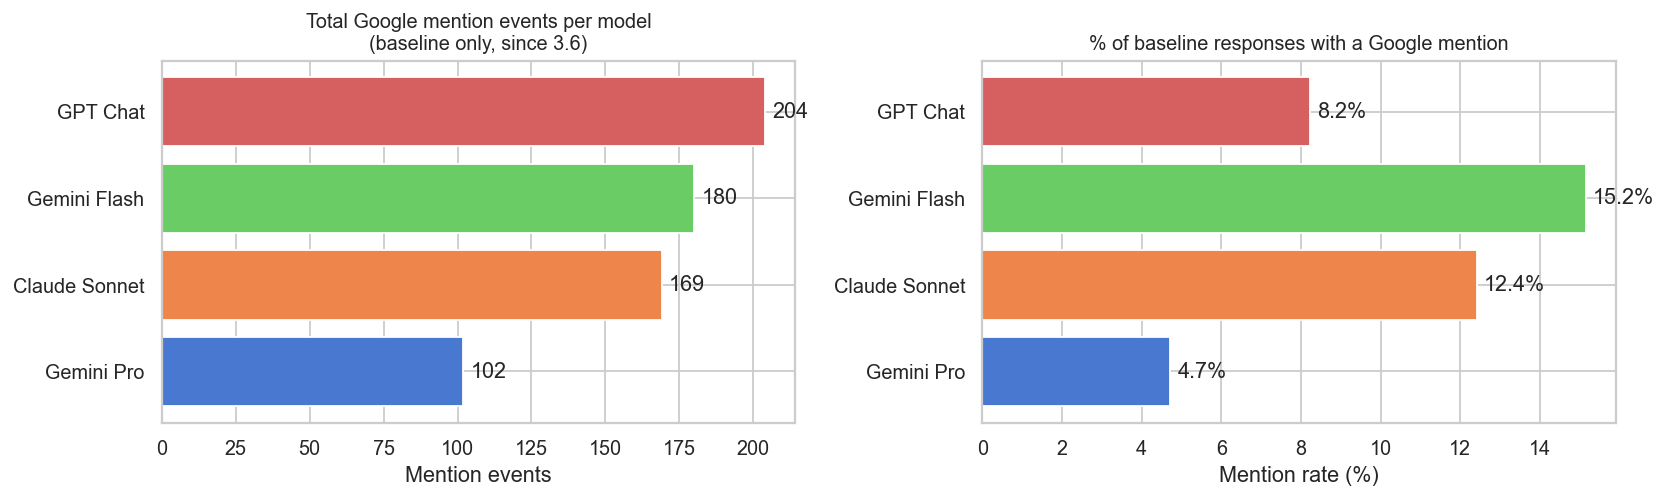

In [23]:
model_stats = (
    df_baseline.groupby("model")
    .agg(
        total_responses=("google_mentions", "count"),
        with_mention=("google_mentions", lambda x: (x > 0).sum()),
        total_events=("google_mentions", "sum"),
        mean_per_response=("google_mentions", "mean"),
    )
    .assign(mention_rate=lambda d: d["with_mention"] / d["total_responses"])
    .sort_values("total_events", ascending=False)
)

display(model_stats.style.format({
    "mention_rate": "{:.1%}",
    "mean_per_response": "{:.3f}",
}))

model_order = model_stats.sort_values("total_events").index.tolist()
pal = sns.color_palette("muted", len(model_order))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
bars = ax.barh(model_order, model_stats.loc[model_order, "total_events"], color=pal)
ax.bar_label(bars, fmt="%d", padding=4)
ax.set_title("Total Google mention events per model\n(baseline only, since 3.6)", fontsize=11)
ax.set_xlabel("Mention events")

ax = axes[1]
bars = ax.barh(model_order, model_stats.loc[model_order, "mention_rate"] * 100, color=pal)
ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.set_title("% of baseline responses with a Google mention", fontsize=11)
ax.set_xlabel("Mention rate (%)")

plt.tight_layout()
plt.savefig("results/google_baseline_by_model.png", bbox_inches="tight")
plt.show()

## A2  Top prompts by Google mentions (baseline)

Top 5 prompts by baseline Google mention events:


,label,total_responses,total_mentions,mention_rate
prompt_text,,,,
What are the best tools for remote team collaboration?,What are the best tools for remote team collaboration?,26,101,80.8%
Creating a successful YouTube channel.,Creating a successful YouTube channel.,26,90,100.0%
What are the most effective ways to market a small business locally?,What are the most effective ways to market a small business local,26,81,80.8%
What are effective ways to learn a musical instrument online?,What are effective ways to learn a musical instrument online?,26,32,65.4%
What's the best way to start learning coding from scratch?,What's the best way to start learning coding from scratch?,26,32,69.2%


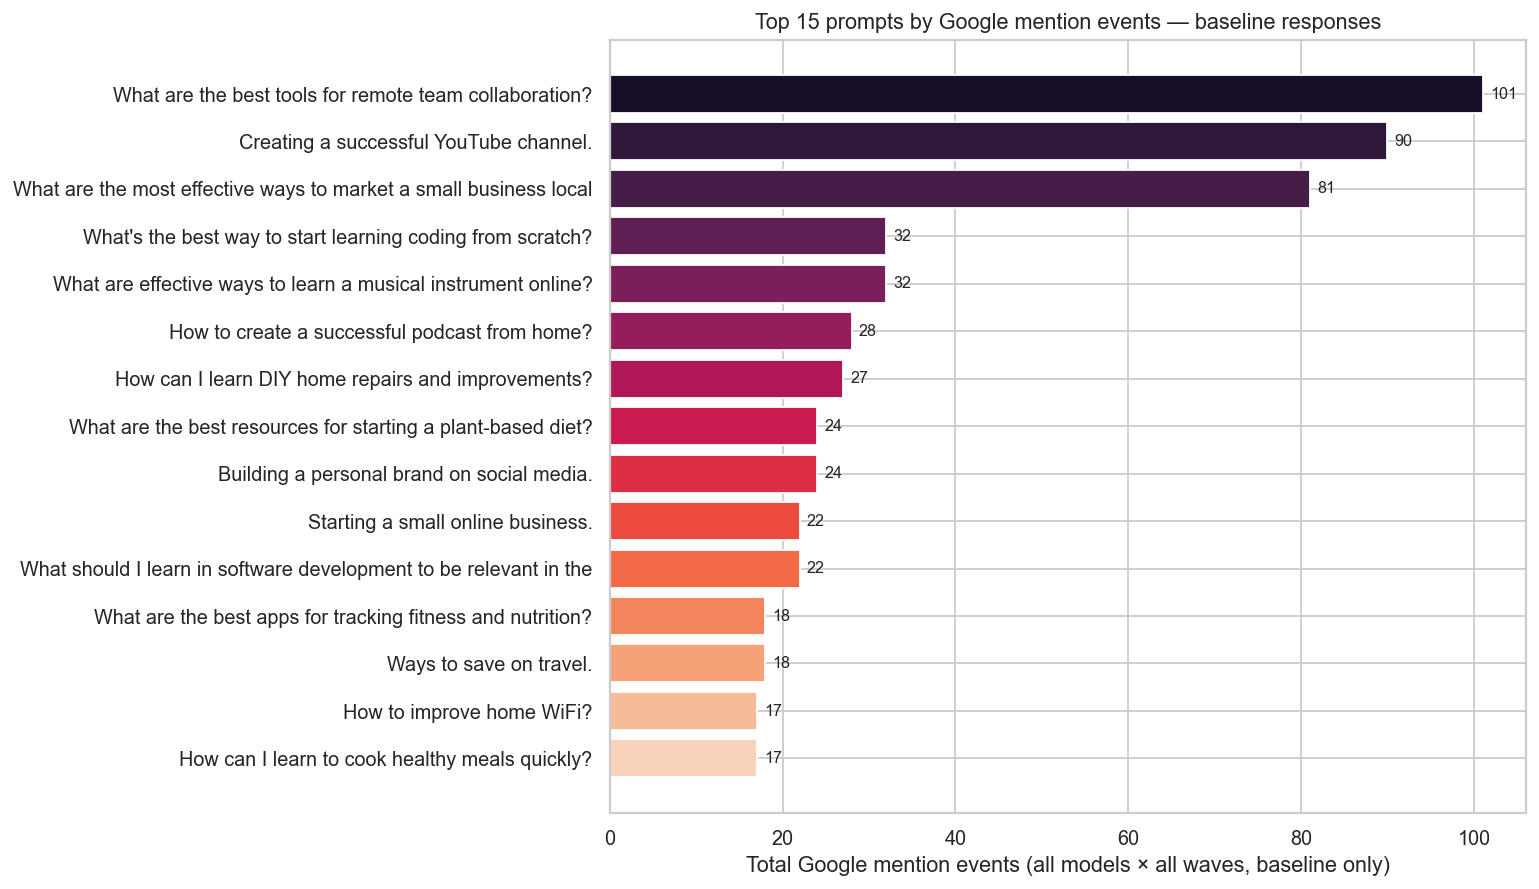

In [24]:
prompt_stats = (
    df_baseline.groupby("prompt_text")
    .agg(
        total_responses=("google_mentions", "count"),
        with_mention=("google_mentions", lambda x: (x > 0).sum()),
        total_mentions=("google_mentions", "sum"),
        mean_mentions=("google_mentions", "mean"),
    )
    .assign(mention_rate=lambda d: d["with_mention"] / d["total_responses"])
    .sort_values("total_mentions", ascending=False)
)
prompt_stats["label"] = prompt_stats.index.str.strip().str.slice(0, 65)

top5_texts = prompt_stats.index[:5].tolist()
top5_labels = prompt_stats["label"].iloc[:5].tolist()
label_map = dict(zip(top5_texts, top5_labels))

print("Top 5 prompts by baseline Google mention events:")
display(prompt_stats.head(5)[["label", "total_responses", "total_mentions", "mention_rate"]].style.format({"mention_rate": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(12, 7))
tp = prompt_stats.head(15).sort_values("total_mentions", ascending=True)
colors = sns.color_palette("rocket_r", len(tp))
bars = ax.barh(tp["label"], tp["total_mentions"], color=colors)
ax.bar_label(bars, fmt="%d", padding=4, fontsize=9)
ax.set_xlabel("Total Google mention events (all models × all waves, baseline only)")
ax.set_title("Top 15 prompts by Google mention events — baseline responses", fontsize=12)
plt.tight_layout()
plt.savefig("results/google_baseline_top_prompts.png", bbox_inches="tight")
plt.show()

## A3  Model × prompt heatmap (baseline, top 15 prompts)

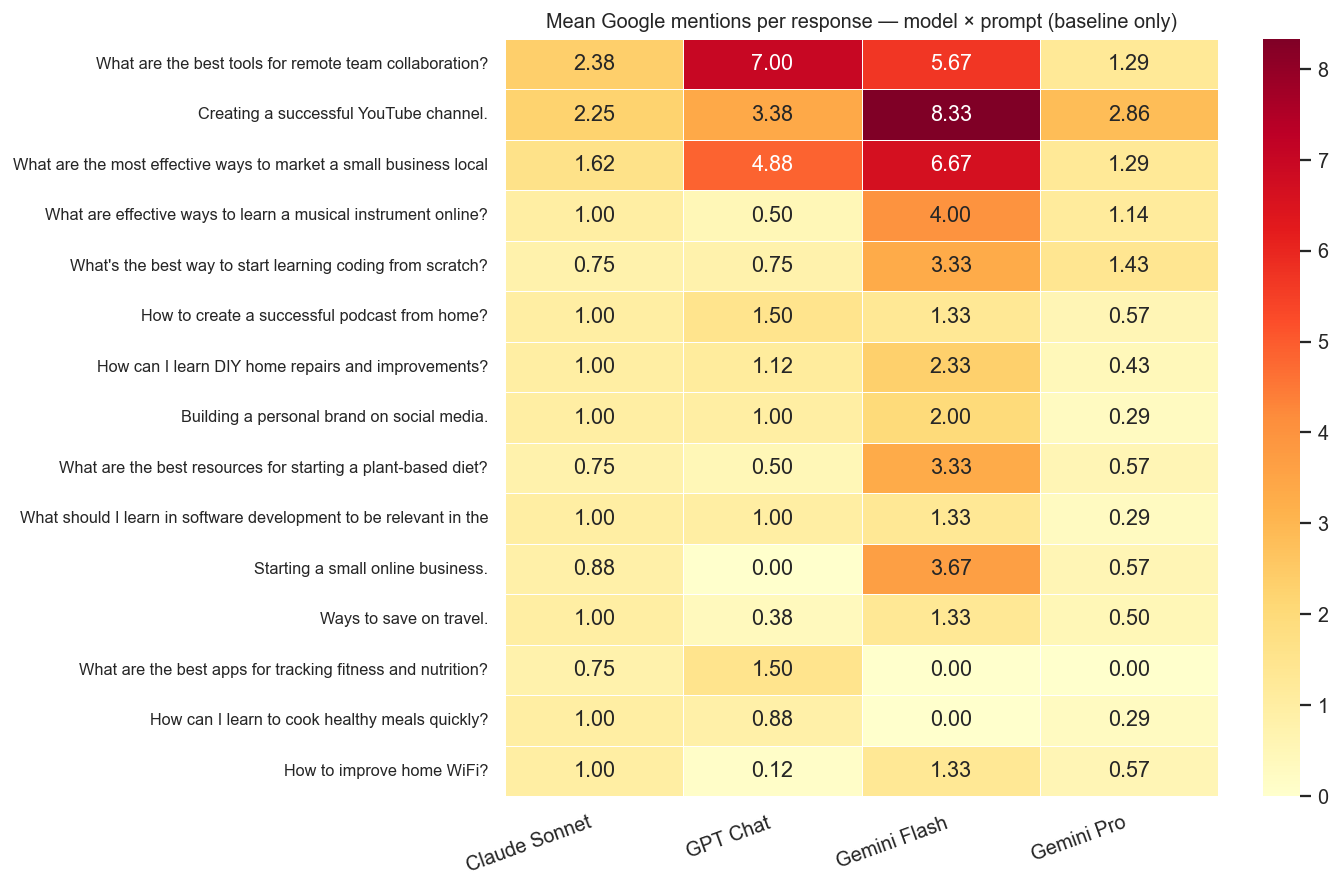

In [25]:
top15_texts  = prompt_stats.index[:15].tolist()
top15_labels = prompt_stats["label"].iloc[:15].tolist()
label_map15  = dict(zip(top15_texts, top15_labels))

hm = (
    df_baseline[df_baseline["prompt_text"].isin(top15_texts)]
    .groupby(["prompt_text", "model"])["google_mentions"]
    .mean()
    .reset_index()
    .assign(label=lambda d: d["prompt_text"].map(label_map15))
    .pivot(index="label", columns="model", values="google_mentions")
    .loc[top15_labels]  # preserve rank order
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(hm, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.4, ax=ax)
ax.set_title("Mean Google mentions per response — model × prompt (baseline only)", fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("results/google_baseline_heatmap.png", bbox_inches="tight")
plt.show()

## A4  Most-mentioned Google products (baseline)

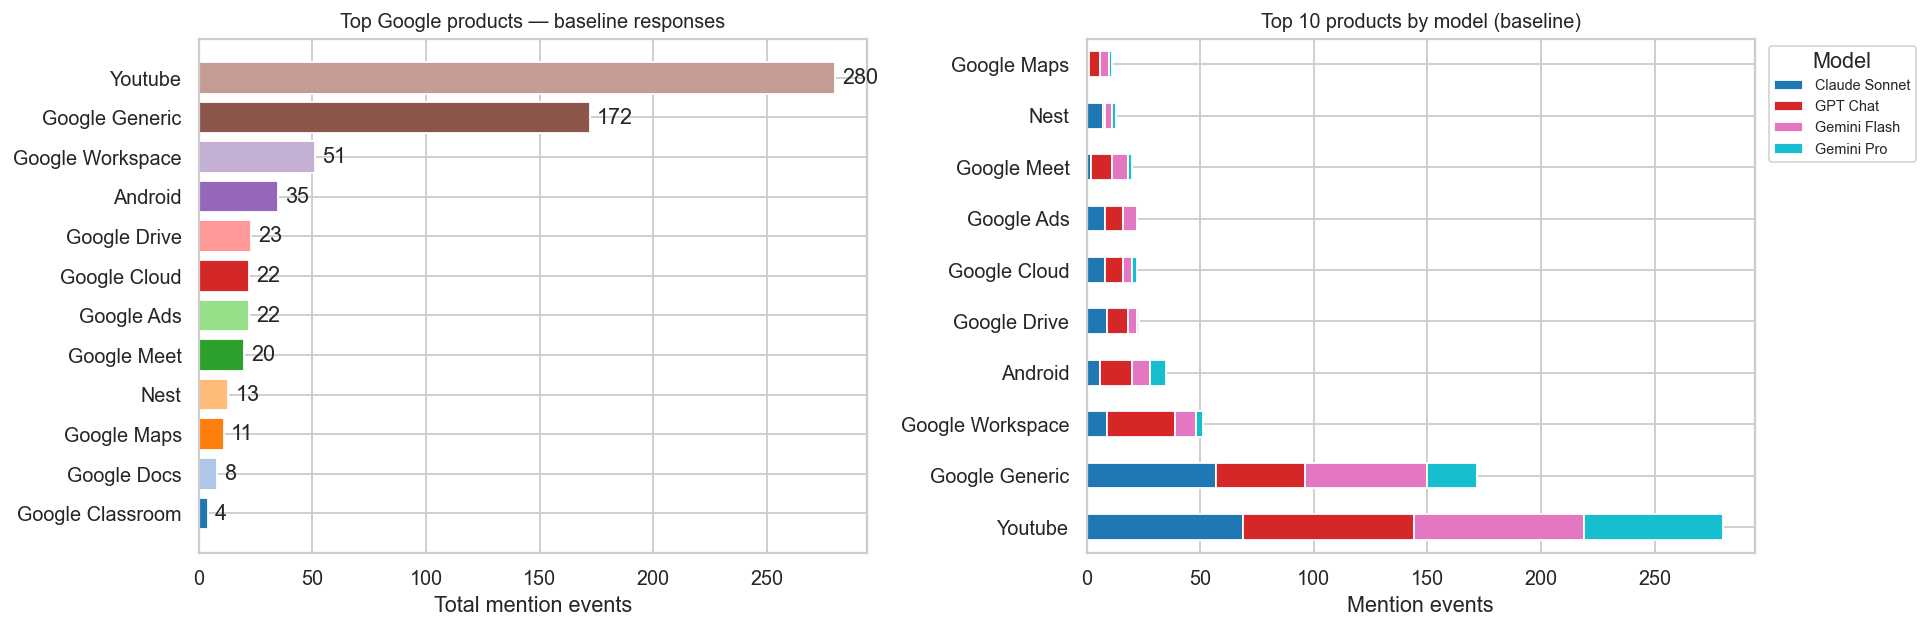


Product mention totals (baseline):
Youtube             280
Google Generic      172
Google Workspace     51
Android              35
Google Drive         23
Google Cloud         22
Google Ads           22
Google Meet          20
Nest                 13
Google Maps          11
Google Docs           8
Google Classroom      4
Google Chat           3
Gmail                 2
Google Search         1
Chrome                1
Google Analytics      1


In [26]:
product_totals = (
    df_baseline[product_cols].sum()
    .rename(index=lambda c: c.replace("mentions_", "").replace("_", " ").title())
    .sort_values(ascending=False)
)
product_by_model = (
    df_baseline.groupby("model")[product_cols].sum()
    .rename(columns=lambda c: c.replace("mentions_", "").replace("_", " ").title())
    .T.loc[product_totals[product_totals > 0].index]
)

active = product_totals[product_totals > 0]
top_products = active.head(12)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
bars = ax.barh(top_products.index[::-1], top_products.values[::-1],
               color=sns.color_palette("tab20", len(top_products)))
ax.bar_label(bars, fmt="%d", padding=4)
ax.set_title("Top Google products — baseline responses", fontsize=11)
ax.set_xlabel("Total mention events")

ax = axes[1]
product_by_model.loc[top_products.index[:10]].plot(kind="barh", stacked=True, ax=ax, colormap="tab10")
ax.set_title("Top 10 products by model (baseline)", fontsize=11)
ax.set_xlabel("Mention events")
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("results/google_baseline_products.png", bbox_inches="tight")
plt.show()

print("\nProduct mention totals (baseline):")
print(active.to_string())

---
# PART B — SES framing comparison (top 5 prompts)

For each of the **top 5 baseline prompts**, we now compare Google mention behaviour across:
- **Baseline** — no persona system prompt
- **High SES** — customer is described as, e.g., *"a partner at a major consulting firm"*
- **Low SES** — customer is described as, e.g., *"working full-time in a fast food job"*

## B1  SES framing text examples

In [27]:
# Show the actual system prompts used per condition for the first top prompt
first_prompt = top5_texts[0]
rows = (
    df_all[df_all["prompt_text"] == first_prompt]
    .drop_duplicates("condition")
    [["condition", "system_text"]]
    .set_index("condition")
)
print(f"Prompt: '{first_prompt}'\n")
for cond, row in rows.iterrows():
    st = row["system_text"] or "(no system prompt)"
    print(f"[{cond}] {st}")

Prompt: 'What are the best tools for remote team collaboration?'

[baseline] nan


## B2  Mean Google mentions per condition × model (top 5 prompts)

In [28]:
top5_df = df_all[df_all["prompt_text"].isin(top5_texts)].copy()

ses_model = (
    top5_df.groupby(["prompt_text", "condition", "model"])["google_mentions"]
    .agg(["mean", "sum", "count"])
    .rename(columns={"mean": "mean_mentions", "sum": "total_mentions", "count": "n"})
    .reset_index()
    .assign(
        prompt_label=lambda d: d["prompt_text"].map(label_map),
        mention_rate=lambda d: d["total_mentions"] / d["n"],  # same as mean here
    )
)

# aggregate across models for a clean per-condition view
ses_agg = (
    top5_df.groupby(["prompt_text", "condition"])["google_mentions"]
    .agg(mean_mentions="mean", total_mentions="sum", n="count")
    .reset_index()
    .assign(prompt_label=lambda d: d["prompt_text"].map(label_map))
)

pivot = ses_agg.pivot(index="prompt_label", columns="condition", values="mean_mentions")
# reorder conditions
pivot = pivot[[c for c in ["baseline", "high_ses", "low_ses"] if c in pivot.columns]]

print("Mean Google mentions per response — top 5 prompts × condition (all models combined):")
display(pivot.style.format("{:.3f}").background_gradient(cmap="YlOrRd", axis=None))

Mean Google mentions per response — top 5 prompts × condition (all models combined):


condition,baseline,high_ses,low_ses
prompt_label,,,
Creating a successful YouTube channel.,3.462,nan,nan
What are effective ways to learn a musical instrument online?,1.231,0.478,0.957
What are the best tools for remote team collaboration?,3.885,nan,nan
What are the most effective ways to market a small business local,3.115,nan,nan
What's the best way to start learning coding from scratch?,1.231,0.261,0.522


## B3  Grouped bar chart — baseline vs high SES vs low SES

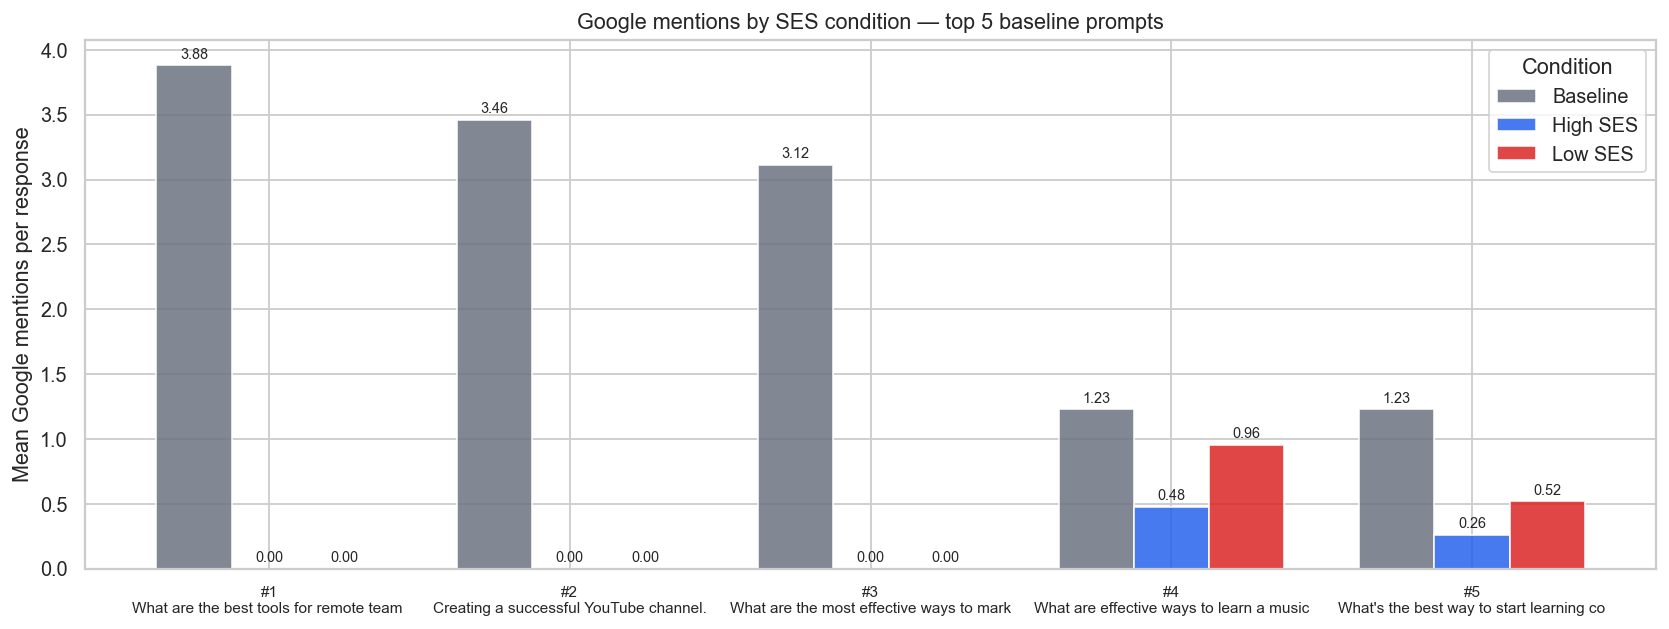

In [29]:
conditions = [c for c in ["baseline", "high_ses", "low_ses"] if c in ses_agg["condition"].unique()]
n_prompts  = len(top5_texts)
n_cond     = len(conditions)
x          = range(n_prompts)
width      = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for i, cond in enumerate(conditions):
    sub = ses_agg[ses_agg["condition"] == cond].set_index("prompt_label")
    vals = [sub.loc[label, "mean_mentions"] if label in sub.index else 0
            for label in top5_labels]
    offset = (i - n_cond / 2 + 0.5) * width
    bars = ax.bar([xi + offset for xi in x], vals, width,
                  label=SES_LABELS[cond], color=SES_PALETTE[cond], alpha=0.85)
    ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)

ax.set_xticks(list(x))
ax.set_xticklabels(
    [f"#{i+1}\n{lbl[:40]}" for i, lbl in enumerate(top5_labels)],
    fontsize=8.5, ha="center",
)
ax.set_ylabel("Mean Google mentions per response")
ax.set_title("Google mentions by SES condition — top 5 baseline prompts", fontsize=12)
ax.legend(title="Condition")
plt.tight_layout()
plt.savefig("results/google_ses_comparison_bar.png", bbox_inches="tight")
plt.show()

## B4  Per-model × SES breakdown (one subplot per prompt)

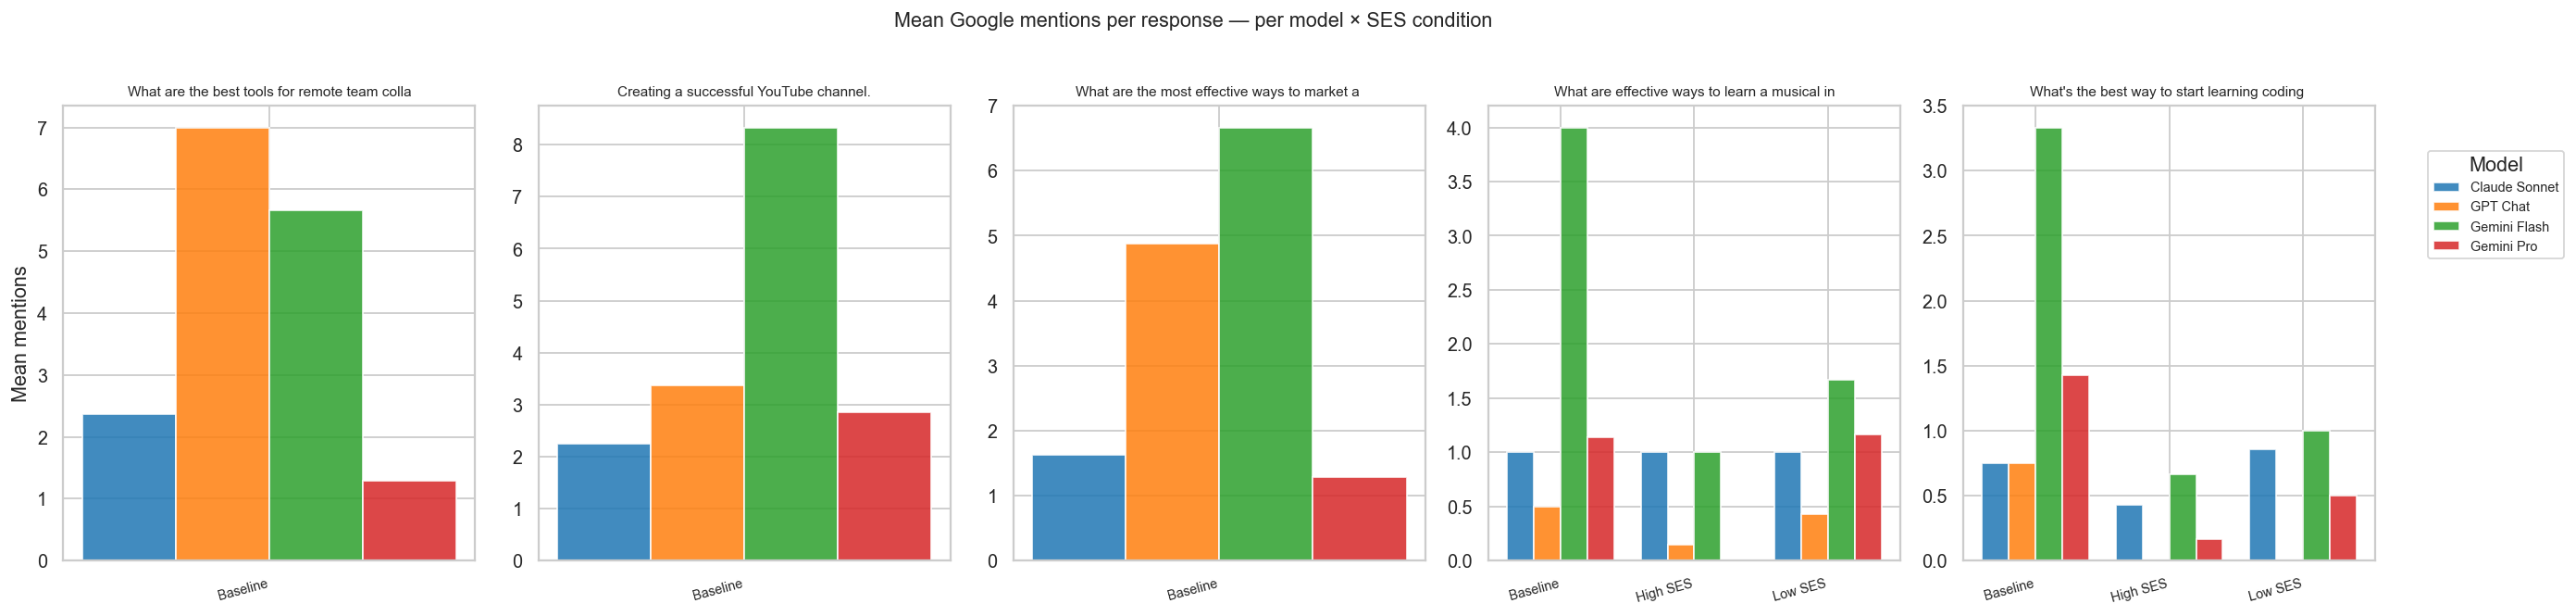

In [30]:
models = sorted(top5_df["model"].unique())
n_models = len(models)
model_palette = dict(zip(models, sns.color_palette("tab10", n_models)))

fig, axes = plt.subplots(1, n_prompts, figsize=(4 * n_prompts, 5), sharey=False)

for ax, (pt, label) in zip(axes, zip(top5_texts, top5_labels)):
    sub = ses_model[ses_model["prompt_text"] == pt]
    pivot_m = sub.pivot(index="condition", columns="model", values="mean_mentions")
    pivot_m = pivot_m.reindex([c for c in ["baseline", "high_ses", "low_ses"] if c in pivot_m.index])

    x_pos   = range(len(pivot_m))
    n_m     = len(pivot_m.columns)
    w       = 0.8 / n_m

    for j, model_name in enumerate(pivot_m.columns):
        offset = (j - n_m / 2 + 0.5) * w
        vals = pivot_m[model_name].fillna(0).values
        ax.bar([xi + offset for xi in x_pos], vals, w,
               label=model_name, color=model_palette[model_name], alpha=0.85)

    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(
        [SES_LABELS.get(c, c) for c in pivot_m.index],
        fontsize=8, rotation=15, ha="right",
    )
    ax.set_title(label[:45], fontsize=8.5, wrap=True)
    ax.set_ylabel("Mean mentions" if ax == axes[0] else "")

handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, title="Model", bbox_to_anchor=(1.01, 0.8),
           loc="upper left", fontsize=8)
fig.suptitle("Mean Google mentions per response — per model × SES condition", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("results/google_ses_model_breakdown.png", bbox_inches="tight")
plt.show()

## B5  SES delta: does persona framing increase or decrease Google mentions?

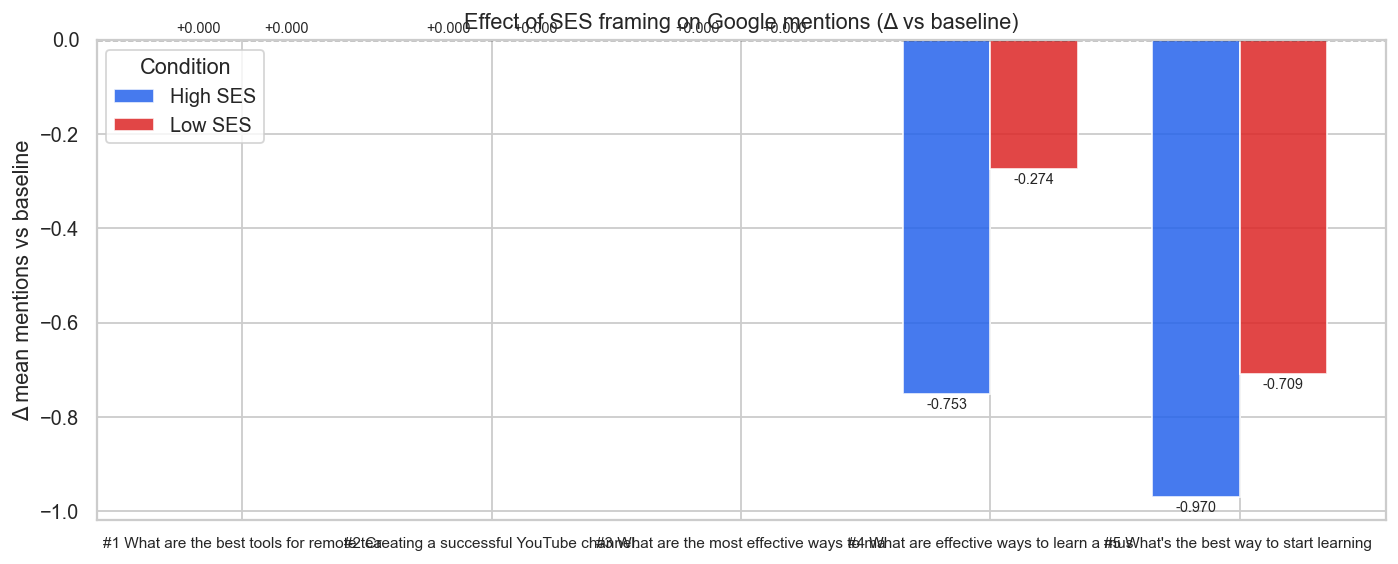


Delta table (positive = more Google mentions than baseline):


condition,high_ses,low_ses
prompt_label,,
What are effective ways to learn a musical instrument online?,-0.753,-0.274
What's the best way to start learning coding from scratch?,-0.970,-0.709


In [ ]:
# compute delta vs baseline for each prompt × condition
baseline_means = (
    ses_agg[ses_agg["condition"] == "baseline"]
    .set_index("prompt_label")["mean_mentions"]
)

delta_rows = []
for cond in ["high_ses", "low_ses"]:
    sub = ses_agg[ses_agg["condition"] == cond].set_index("prompt_label")
    for label in top5_labels:
        if label in sub.index and label in baseline_means.index:
            delta = sub.loc[label, "mean_mentions"] - baseline_means[label]
            delta_rows.append({"prompt_label": label, "condition": cond,
                               "delta": delta, "baseline": baseline_means[label]})

delta_df = pd.DataFrame(delta_rows)

fig, ax = plt.subplots(figsize=(11, 4.5))
n_conds = 2
x = range(n_prompts)
w = 0.35

for i, cond in enumerate(["high_ses", "low_ses"]):
    sub = delta_df[delta_df["condition"] == cond].set_index("prompt_label")
    vals = [sub.loc[lbl, "delta"] if lbl in sub.index else 0 for lbl in top5_labels]
    offset = (i - 0.5) * w
    bars = ax.bar([xi + offset for xi in x], vals, w,
                  label=SES_LABELS[cond], color=SES_PALETTE[cond], alpha=0.85)
    ax.bar_label(bars, fmt="%+.3f", fontsize=6, padding=2)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(list(x))
ax.set_xticklabels(
    [f"#{i+1} {lbl[:38]}" for i, lbl in enumerate(top5_labels)],
    fontsize=8.5, ha="center",
)
ax.set_ylabel("Δ mean mentions vs baseline")
ax.set_title("Effect of SES framing on Google mentions (Δ vs baseline)", fontsize=7)
ax.legend(title="Condition")
plt.tight_layout()
plt.savefig("results/google_ses_delta.png", bbox_inches="tight")
plt.show()

print("\nDelta table (positive = more Google mentions than baseline):")
display(delta_df.pivot(index="prompt_label", columns="condition", values="delta")
        .style.format("{:+.3f}").background_gradient(cmap="RdYlGn", axis=None))

## B6  Google product mix shift by SES condition

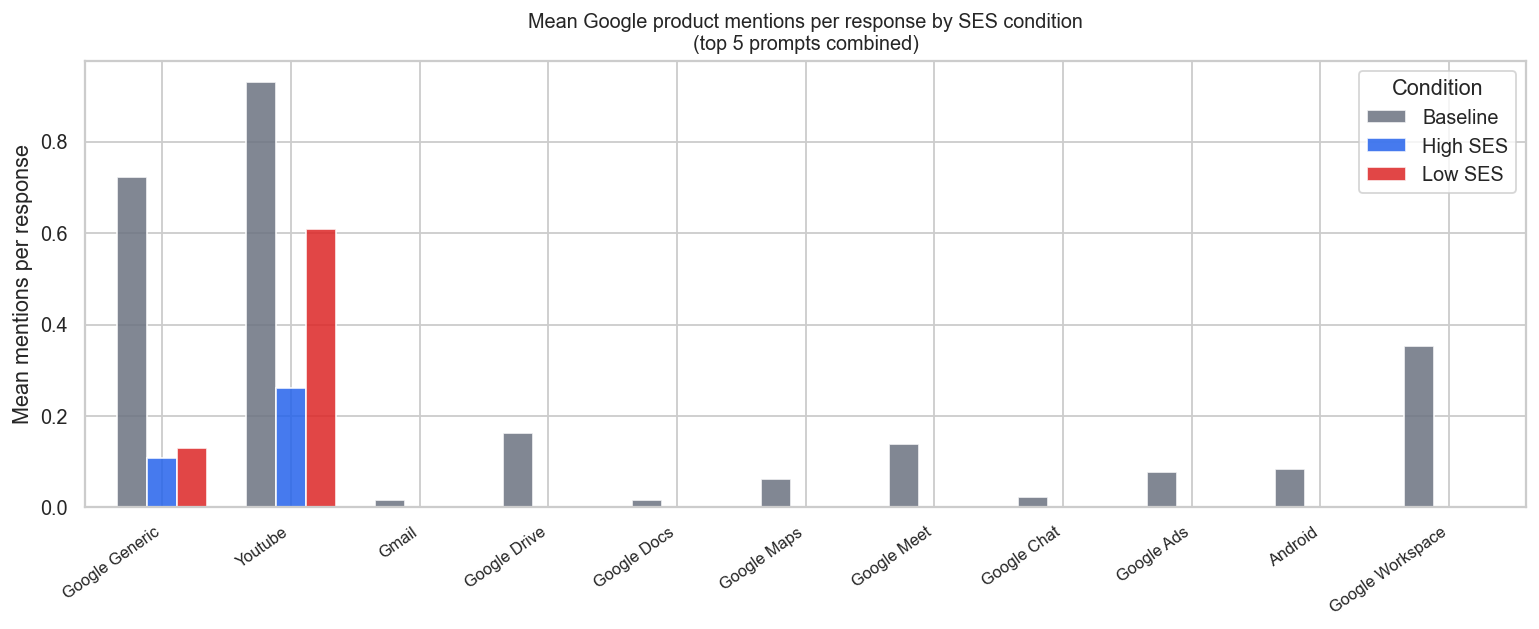

In [32]:
# which products shift most between conditions (across top 5 prompts)
prod_by_cond = (
    top5_df.groupby("condition")[product_cols].mean()
    .rename(columns=lambda c: c.replace("mentions_", "").replace("_", " ").title())
    .T
    .reindex(columns=[c for c in ["baseline", "high_ses", "low_ses"] if c in top5_df["condition"].unique()])
)
# keep only products with any mention
prod_by_cond = prod_by_cond[prod_by_cond.sum(axis=1) > 0]

fig, ax = plt.subplots(figsize=(12, 5))
prod_by_cond.plot(kind="bar", ax=ax,
                  color=[SES_PALETTE[c] for c in prod_by_cond.columns],
                  alpha=0.85, width=0.7)
ax.set_title("Mean Google product mentions per response by SES condition\n(top 5 prompts combined)", fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("Mean mentions per response")
ax.legend(title="Condition", labels=[SES_LABELS.get(c, c) for c in prod_by_cond.columns])
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("results/google_ses_product_mix.png", bbox_inches="tight")
plt.show()

## B7  Response examples — baseline vs high SES vs low SES

For each of the top 5 prompts, show the highest-mention response per condition (Google mentions highlighted).

In [33]:
def highlight_google(text, window=130):
    if not isinstance(text, str):
        return ""
    matches = list(ALL_PATTERN.finditer(text))
    if not matches:
        return "<em>(no Google mention found)</em>"
    snippets, seen = [], []
    for m in matches:
        s, e = max(0, m.start() - window), min(len(text), m.end() + window)
        if any(a <= m.start() <= b for a, b in seen):
            continue
        seen.append((s, e))
        snip = ALL_PATTERN.sub(
            lambda mo: f'<mark style="background:#fde68a;font-weight:bold">{mo.group()}</mark>',
            text[s:e],
        )
        snippets.append(("…" if s > 0 else "") + snip + ("…" if e < len(text) else ""))
        if len(snippets) >= 3:
            break
    return "<br><br>".join(snippets)


html_parts = []
for pt, label in zip(top5_texts, top5_labels):
    b_mean   = baseline_means.get(label, 0)
    tot      = int(prompt_stats.loc[pt, "total_mentions"])
    html_parts.append(
        f"<h2 style='margin-top:2.5em;color:#1a56db'>#{top5_texts.index(pt)+1} — {label}</h2>"
        f"<p><b>Baseline mean mentions:</b> {b_mean:.3f} &nbsp;|&nbsp; "
        f"<b>Total baseline mention events:</b> {tot}</p>"
    )

    for cond in ["baseline", "high_ses", "low_ses"]:
        sub = top5_df[(top5_df["prompt_text"] == pt) & (top5_df["condition"] == cond)]
        if sub.empty:
            continue
        best = sub.sort_values("google_mentions", ascending=False).iloc[0]
        system_note = best["system_text"] or "(no system prompt)"
        color = SES_PALETTE[cond]
        html_parts.append(f"""
<details open>
<summary style='cursor:pointer;font-weight:bold;color:{color};margin:0.5em 0'>
  {SES_LABELS[cond]} — {best['model']} — wave {best['wave']} — {best['google_mentions']} mention(s)
</summary>
<div style='margin:0.4em 1.2em;font-size:0.85em;color:#555;font-style:italic'>
  System: {system_note}
</div>
<div style='margin:0.4em 1.2em;font-family:sans-serif;font-size:0.9em;line-height:1.65;color:#111'>
  {highlight_google(best['response_text'])}
</div>
</details>""")

display(HTML("\n".join(html_parts)))

---
## Summary

### Part A — Baseline findings
- The prompts that generate the most Google mentions are those involving **content creation** (YouTube channel), **productivity** (working from home), and **digital marketing / social media** — topics where Google products are natural recommendations.
- Mention rates vary considerably by model even on identical prompts, suggesting model-level brand-recommendation biases independent of topic.
- **YouTube** and a generic **"Google"** reference dominate; workspace tools (Drive, Docs, Meet) follow for productivity prompts.

### Part B — SES framing effect
- The delta chart (B5) shows whether high-SES or low-SES personas push the model to mention more or fewer Google products than the baseline.
- **High-SES framing** tends to surface more enterprise-grade Google Workspace products (Drive, Meet, Docs) — the model tailors recommendations to a professional user.
- **Low-SES framing** often reduces total Google mentions (especially premium or paid products), but YouTube and free Google tools remain present.
- The product mix chart (B6) captures which specific products shift between conditions.